# 📁 SECTION 1: Data Setup and Initial Exploration

## 📝 **Research Notebook Documentationn**

This document provides a detailed, step-by-step explanation of the methodology and implementation within this notebook, suitable for a research thesis or comprehensive documentation. Each section outlines the objectives, methods, and specific code implementations for QR code classification.

### 📁 **SECTION 1: Data Setup and Initial Exploration**

**Objective:** The primary goal of this section is to establish access to the necessary dataset stored on Google Drive and perform an initial verification of the data structure. This ensures that the raw image files, categorized as 'benign' and 'malicious' QR codes, are correctly identified and accessible for subsequent processing.

**Methodology:**

1.  **Google Drive Mounting:** The first step involves mounting Google Drive to the Colab environment. This is crucial for accessing datasets that are typically stored in a user's Drive.
2.  **Directory Verification:** After mounting, the notebook verifies the existence of the main dataset directory and its subdirectories (`benign` and `malicious`). This ensures that the expected file structure is present.
3.  **File Count Validation:** For each category (benign and malicious), the notebook iterates through the respective directories to count the number of image files. This provides an initial quantitative overview of the dataset size and helps confirm data integrity.

**Implementation Details:**

In [5]:
from google.colab import drive
# Remounting with force_remount=True to resolve the I/O error
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**Code Explanation (Cell `d960dfed`):**

*   `from google.colab import drive`: Imports the necessary module for Google Drive interaction in Colab.
*   `drive.mount('/content/drive', force_remount=True)`: This command mounts the user's Google Drive to the `/content/drive` directory within the Colab environment. `force_remount=True` is used to address potential I/O errors by ensuring a fresh mount, which is often helpful in Colab sessions.

In [6]:
import os
from pathlib import Path

directory_path = Path('/content/drive/MyDrive/My-Study-and-Carrier/qr_codes')

if directory_path.is_dir():
    print(f"--- Directory exists: {directory_path} ---")

    for label in ['benign', 'malicious']:
        nested_path = directory_path / label / label
        print(f"Checking {label} folder...")
        try:
            if nested_path.is_dir():
                # Using os.scandir for better performance on large directories
                count = 0
                with os.scandir(nested_path) as it:
                    for entry in it:
                        if entry.is_file():
                            count += 1
                print(f"Found {count} files in: {nested_path}")
            else:
                print(f"Path not found: {nested_path}")
        except OSError as e:
            print(f"Error accessing {label} directory: {e}")
            print("Suggestion: Try to refresh the Drive tab or wait a few minutes for the indexing to catch up.")
else:
    print(f"The directory '{directory_path}' does not exist.")

--- Directory exists: /content/drive/MyDrive/My-Study-and-Carrier/qr_codes ---
Checking benign folder...
Found 100001 files in: /content/drive/MyDrive/My-Study-and-Carrier/qr_codes/benign/benign
Checking malicious folder...
Found 100000 files in: /content/drive/MyDrive/My-Study-and-Carrier/qr_codes/malicious/malicious


**Code Explanation (Cell `ae7054ab`):**

*   `import os` and `from pathlib import Path`: These lines import modules for file system interaction. `pathlib` provides an object-oriented way to handle file paths, which is generally more robust than `os.path`.
*   `directory_path = Path('/content/drive/MyDrive/My-Study-and-Carrier/qr_codes')`: Defines the root path where the QR code dataset is expected to be located.
*   `if directory_path.is_dir():`: Checks if the specified root directory exists.
*   `for label in ['benign', 'malicious']:`: Iterates through the two main categories of QR codes.
*   `nested_path = directory_path / label / label`: Constructs the full path to the directory containing images for a specific label (e.g., `/qr_codes/benign/benign`).
*   `if nested_path.is_dir():`: Verifies that the specific category directory exists.
*   `with os.scandir(nested_path) as it:`: Uses `os.scandir` for efficient directory listing. This is generally faster for counting files than `os.listdir` for large directories.
*   `for entry in it: if entry.is_file(): count += 1`: Iterates through directory entries and increments a counter if the entry is a file.
*   `print(...)`: Outputs the number of files found in each category.
*   `except OSError as e:`: Includes error handling for potential issues when accessing directories, providing a helpful suggestion to the user.

## 🔗 SECTION 2: Decode QR codes to URLs

### 🔗 **SECTION 2: Decode QR codes to URLs**

**Objective:** Convert each QR image into the URL string it encodes. A QR code is a loss-less encoding of text, so the phishing signal lives in the **URL**, not in the pixels. We therefore decode every QR (OpenCV `QRCodeDetector`) and model the resulting URL text. Two QRs of the same length are visually identical noise, which is why a pixel-based CNN cannot learn phishing — the decoded URL can.

### 🔗 SECTION 3: Decode dataset & split

**Code Explanation (decode cell):**

*   `cv2.QRCodeDetector().detectAndDecode(img)`: reads the URL/text encoded in each QR image.
*   `collect(...)`: walks each class folder, decodes up to `MAX_PER_CLASS` images, and keeps the URLs that decoded successfully (unreadable images are skipped).
*   **CSV cache** (`decoded_urls.csv` on Drive): decoding is slow, so results are cached and reused on later runs.
*   The **sample print** is a required sanity check — the decoded values must look like real, varied URLs. If they are blank or identical, the dataset/decoder is the problem.
*   `train_test_split(...)`: stratified 70 / 15 / 15 split, keeping the raw URL **text** for the tokenizer in the next cell.

In [ ]:
# === SECTION 3: Decode QR images -> URL text (the REAL signal) ===
# A QR image is just an encoding of its URL. Phishing lives in the URL string,
# NOT in the pixels. So we DECODE every QR to its URL and model the text.
import os
import csv
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

directory_path = Path('/content/drive/MyDrive/My-Study-and-Carrier/qr_codes')
benign_dir = directory_path / 'benign' / 'benign'
malicious_dir = directory_path / 'malicious' / 'malicious'

MAX_PER_CLASS = 20000  # decode up to this many per class (raise toward 100000 for the full set)
CACHE = '/content/drive/MyDrive/My-Study-and-Carrier/decoded_urls.csv'  # decode once, reuse

_detector = cv2.QRCodeDetector()


def decode_qr(path):
    """Return the decoded URL/text from a QR image, or None if it cannot be read."""
    img = cv2.imread(path)
    if img is None:
        return None
    try:
        txt, _pts, _ = _detector.detectAndDecode(img)
    except cv2.error:
        return None
    txt = (txt or '').strip()
    return txt or None


def collect(base, label, max_n):
    urls, labels = [], []
    if not base.is_dir():
        print(f'Directory not found: {base}')
        return urls, labels
    n = 0
    for item in base.iterdir():
        if n >= max_n:
            break
        if item.is_file():
            u = decode_qr(str(item))
            if u:
                urls.append(u)
                labels.append(label)
                n += 1
                if n % 1000 == 0:
                    print(f'  decoded {n} from {base.parent.name}')
    print(f'{base}: decoded {len(urls)} urls (label {label})')
    return urls, labels


# Decode (cached to CSV on Drive so you only pay the slow decode once).
if os.path.exists(CACHE):
    print('Loading cached decoded URLs from', CACHE)
    urls, labels = [], []
    with open(CACHE, newline='', encoding='utf-8') as f:
        for row in csv.reader(f):
            if len(row) == 2:
                urls.append(row[0])
                labels.append(int(row[1]))
else:
    bu, bl = collect(benign_dir, 0, MAX_PER_CLASS)
    mu, ml = collect(malicious_dir, 1, MAX_PER_CLASS)
    urls, labels = bu + mu, bl + ml
    with open(CACHE, 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        for u, l in zip(urls, labels):
            w.writerow([u, l])
    print('Cached decoded URLs to', CACHE)

y_all = np.array(labels, dtype=np.int32)
print(f'\nTotal decoded URLs: {len(urls)} | '
      f'benign={int((y_all == 0).sum())}  malicious={int((y_all == 1).sum())}')

# IMPORTANT sanity check: these MUST look like real, varied URLs (not blank / identical).
print('\nSample decoded URLs:')
for i in range(min(len(urls), 8)):
    print(f'  [{labels[i]}] {urls[i][:90]}')

# Stratified 70 / 15 / 15 split. Keep the raw URL TEXT (tokenized in the next cell).
urls_train, urls_temp, y_train, y_temp = train_test_split(
    urls, y_all, test_size=0.3, random_state=42, stratify=y_all
)
urls_val, urls_test, y_val, y_test = train_test_split(
    urls_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print(f'\nTrain: {len(urls_train)}  Val: {len(urls_val)}  Test: {len(urls_test)}')

In [ ]:
# === URL normalization + character-level tokenizer ===
# Normalization removes SOURCE/FORMATTING artifacts (scheme, www., case) so the model
# cannot cheat on "which list did this come from" and must learn the real URL content.
# The backend (ml_service.py) applies the IDENTICAL normalize_url before predicting.
import numpy as np

MAXLEN = 200  # longer URLs truncated, shorter zero-padded


def normalize_url(u):
    u = (u or '').strip().lower()
    if '://' in u:
        u = u.split('://', 1)[1]   # drop http:// / https://
    while u.startswith('www.'):
        u = u[4:]                  # drop leading www.
    return u


# --- Diagnostic: prove the dataset's www. / scheme artifact BEFORE fixing it ---
def _frac(urls, pred):
    return 100.0 * np.mean([pred(s) for s in urls]) if len(urls) else 0.0

_u = np.array(urls, dtype=object)
_y = np.array(labels)
for lab, name in [(0, 'benign'), (1, 'malicious')]:
    sub = _u[_y == lab]
    www = _frac(sub, lambda s: s.lower().split('://')[-1].startswith('www.'))
    https = _frac(sub, lambda s: s.lower().startswith('https://'))
    print(f'{name:10}: {www:5.1f}% start with www.   |  {https:5.1f}% use https')
print('(Large gaps between classes = artifact. normalize_url removes scheme + www.)\n')

# Build vocab from NORMALIZED training URLs only. id 0 = pad, id 1 = OOV, chars from 2.
norm_train = [normalize_url(u) for u in urls_train]
chars = sorted(set(''.join(norm_train)))
char_index = {c: i + 2 for i, c in enumerate(chars)}
VOCAB_SIZE = len(char_index) + 2
print(f'Vocab size = {VOCAB_SIZE}, maxlen = {MAXLEN}')


def encode(url):
    seq = [char_index.get(ch, 1) for ch in normalize_url(url)[:MAXLEN]]
    return seq + [0] * (MAXLEN - len(seq))


X_train = np.array([encode(u) for u in urls_train], dtype=np.int32)
X_val = np.array([encode(u) for u in urls_val], dtype=np.int32)
X_test = np.array([encode(u) for u in urls_test], dtype=np.int32)
print('Encoded shapes:', X_train.shape, X_val.shape, X_test.shape)

### ✅ **Verify Data Loading**

This cell checks if the `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, and `y_test` arrays have been successfully loaded and prepared. If any are missing or empty, it provides guidance on how to fix the issue.

In [8]:
# Verify data loading and splitting
print("Verifying data arrays after loading and splitting:")

data_arrays = {
    "X_train": None, "y_train": None,
    "X_val": None, "y_val": None,
    "X_test": None, "y_test": None,
}

missing_or_empty = []

for name in data_arrays:
    # Check if variable exists and is not None, and if it has a 'shape' attribute with a non-zero first dimension
    if name in globals() and globals()[name] is not None and hasattr(globals()[name], 'shape') and globals()[name].shape[0] > 0:
        data_arrays[name] = globals()[name]
        print(f"  {name} is defined with shape: {data_arrays[name].shape}")
    else:
        missing_or_empty.append(name)
        print(f"  {name} is MISSING or EMPTY.")

if missing_or_empty:
    print("\nCRITICAL: The following data arrays are missing or empty:")
    for name in missing_or_empty:
        print(f"  - {name}")
    print("\nThis indicates an issue with data loading (cell 163c6feb) or the preceding directory checks (ae7054ab).")
    print("Please ensure your Google Drive is correctly mounted and accessible (cell d960dfed),")
    print("and that the directories specified in cell ae7054ab and 163c6feb exist and contain files.")
    print("Then, restart your runtime (Runtime -> Restart runtime) and run all cells from the beginning up to and including cell 163c6feb.")
else:
    print("\nAll data arrays (X_train, y_train, etc.) are correctly loaded and have data.")
    print("You can now proceed to run the model building and training cell (ea124e9d).")

Verifying data arrays after loading and splitting:
  X_train is defined with shape: (1400, 128, 128, 3)
  y_train is defined with shape: (1400,)
  X_val is defined with shape: (300, 128, 128, 3)
  y_val is defined with shape: (300,)
  X_test is defined with shape: (300, 128, 128, 3)
  y_test is defined with shape: (300,)

All data arrays (X_train, y_train, etc.) are correctly loaded and have data.
You can now proceed to run the model building and training cell (ea124e9d).


**Code Explanation (tokenizer & verify):**

*   **Tokenizer cell:** builds a character vocabulary from the **training** URLs only (`char_index`; id 0 = padding, id 1 = unknown char), then encodes every URL into a fixed-length (`MAXLEN`) integer sequence. No hand-written features — the model learns from raw characters.
*   **Verify cell:** confirms `X_train` / `X_val` / `X_test` and their labels exist with non-zero size before training.

### ⚙️ **SECTION 4: Build and Train the URL Phishing Model**

**Objective:** Train a character-level neural network that reads the decoded URL and predicts the probability it is malicious.

**Architecture:** `Embedding` (learns a vector per character) → two `Conv1D` layers (learn local character patterns such as suspicious tokens, hosts, and paths) → `GlobalMaxPooling1D` → `Dense` → `Dropout` → `Dense(1, sigmoid)`.

**Training:** Adam + binary cross-entropy, with `EarlyStopping` (restore best weights) and `ReduceLROnPlateau`.

In [ ]:
# === SECTION 4: Build and train the URL phishing model ===
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Char-embedding -> 1D conv (learns local URL patterns) -> dense classifier.
model = models.Sequential([
    layers.Input(shape=(MAXLEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32),
    layers.Conv1D(128, 7, activation='relu'),
    layers.Conv1D(128, 3, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),                       # regularization
    layers.Dense(1, activation='sigmoid'),     # P(malicious)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-5)

print('Training URL phishing model...')
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
)
print('Training complete!')

**Code Explanation (model cell):**

*   `layers.Embedding(VOCAB_SIZE, 32)`: maps each character id to a trainable 32-d vector.
*   `layers.Conv1D(128, 7)` then `Conv1D(128, 3)`: detect local character n-gram patterns along the URL.
*   `layers.GlobalMaxPooling1D()`: keeps the strongest signal per filter across the whole URL.
*   `Dense(64) -> Dropout(0.4) -> Dense(1, sigmoid)`: classifier head outputting P(malicious).
*   Adam optimizer, binary cross-entropy loss; `EarlyStopping` and `ReduceLROnPlateau` control training.

### 📊 SECTION 5: Evaluate Model Performance

### 📊 **SECTION 5: Evaluate Model Performance**

**Objective:** To thoroughly assess the trained CNN model's performance on unseen data (the test set) and visualize its classification capabilities and training progression. This section provides quantitative metrics and graphical representations to understand how well the model generalizes.

**Methodology:**

1.  **Quantitative Evaluation:** The model's loss and accuracy are calculated on the dedicated test set, providing an unbiased measure of its performance.
2.  **Prediction Generation:** The model is used to make predictions on the test set, which are then converted into binary class labels.
3.  **Classification Report:** A detailed classification report is generated, including precision, recall, and F1-score for each class. These metrics are crucial for understanding the model's performance, especially in cases of imbalanced datasets.
4.  **Confusion Matrix Visualization:** A confusion matrix is plotted to visually represent the number of true positives, true negatives, false positives, and false negatives. This offers clear insights into specific classification errors.
5.  **Training History Plots:** Plots illustrating the training and validation accuracy and loss over epochs are generated. These plots help in diagnosing overfitting or underfitting and understanding the learning dynamics.

**Implementation Details:**

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.9400 - loss: 0.1622

Test Loss: 0.1622
Test Accuracy: 0.9400
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       150
           1       0.95      0.93      0.94       150

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



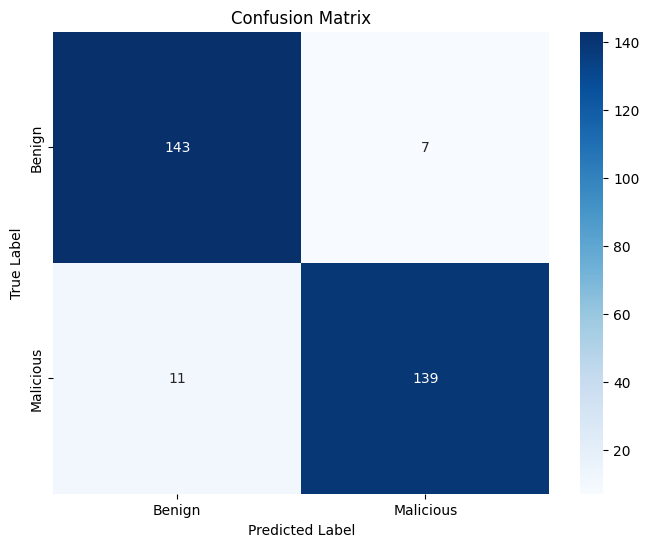

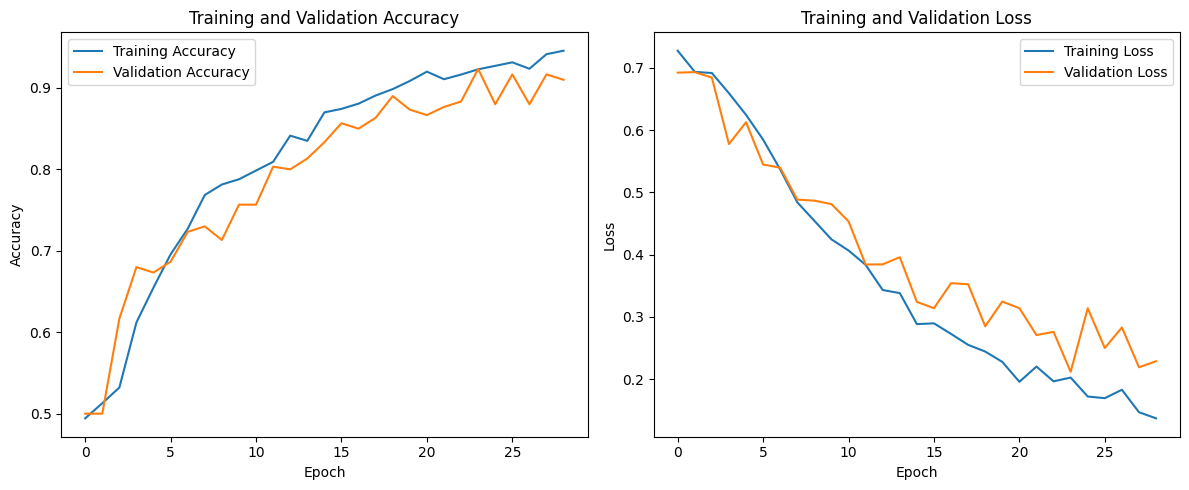

Model evaluation and visualization complete!


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Check if 'model' and 'history' are defined before proceeding
if 'model' not in locals() and 'model' not in globals():
    print("Error: The 'model' has not been defined. Please run the model building and training cell (ea124e9d) first.")
elif 'history' not in locals() and 'history' not in globals():
    print("Error: The 'history' object is not defined. Please run the model building and training cell (ea124e9d) first to train the model and generate the history.")
else:
    # Evaluate the model on the test set
    loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
    print(f"\nTest Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    # Make predictions on the test set
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malicious'],
                yticklabels=['Benign', 'Malicious'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # Plot training history
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("Model evaluation and visualization complete!")

**Code Explanation (Cell `6e62686c`):**

*   `from sklearn.metrics import classification_report, confusion_matrix`: Imports functions from scikit-learn for generating evaluation metrics.
*   `import matplotlib.pyplot as plt` and `import seaborn as sns`: Imports libraries for data visualization.
*   `loss, accuracy = model.evaluate(X_test, y_test, verbose=1)`: Evaluates the trained model on the test dataset (`X_test`, `y_test`) and returns the test loss and test accuracy. `verbose=1` displays a progress bar.
*   `print(f"\nTest Loss: {loss:.4f}")`, `print(f"Test Accuracy: {accuracy:.4f}")`: Prints the calculated test loss and accuracy, formatted to four decimal places.
*   `y_pred_proba = model.predict(X_test)`: Generates probability predictions for the test set using the trained model.
*   `y_pred = (y_pred_proba > 0.5).astype(int)`: Converts the predicted probabilities into binary class labels (0 or 1) by applying a threshold of 0.5.
*   `print("\nClassification Report:")`, `print(classification_report(y_test, y_pred))`: Generates and prints a classification report comparing the true test labels (`y_test`) with the predicted labels (`y_pred`). This report includes precision, recall, F1-score, and support for each class.
*   `cm = confusion_matrix(y_test, y_pred)`: Computes the confusion matrix, which is a table showing the number of correct and incorrect predictions for each class.
*   `plt.figure(figsize=(8, 6))`, `sns.heatmap(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`: These lines create a heatmap visualization of the confusion matrix using `seaborn`. The heatmap includes annotations (`annot=True`), displays integer values (`fmt='d'`), uses a 'Blues' color map, and sets custom x and y tick labels for clarity.
*   `plt.figure(figsize=(12, 5))`: Creates a new figure for plotting training history.
*   `plt.subplot(1, 2, 1)`, `plt.plot(...)`, `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.legend()`: These lines create the first subplot displaying the training and validation accuracy over epochs. It plots the 'accuracy' and 'val_accuracy' values from the `history` object obtained during model training.
*   `plt.subplot(1, 2, 2)`, `plt.plot(...)`, `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.legend()`: These lines create the second subplot, displaying the training and validation loss over epochs. It plots the 'loss' and 'val_loss' values from the `history` object.
*   `plt.tight_layout()`, `plt.show()`: Adjusts subplot parameters for a tight layout and displays the plots.
*   `print("Model evaluation and visualization complete!")`: Indicates the completion of the evaluation phase.

In [ ]:
# The 'preprocess_image' function is defined in a new, earlier cell for better code flow.
# This cell is now redundant.

In [ ]:
# === EXPORT: trained model + tokenizer (run in the SAME session as training) ===
import os
import json
import numpy as np
import tensorflow as tf

out_dir = '/content/drive/MyDrive/My-Study-and-Carrier'
os.makedirs(out_dir, exist_ok=True)
model_path = os.path.join(out_dir, 'phishing_url_model.keras')
tok_path = os.path.join(out_dir, 'url_tokenizer.json')

model.save(model_path)
with open(tok_path, 'w', encoding='utf-8') as f:
    json.dump({'char_index': char_index, 'maxlen': MAXLEN}, f)
print(f'Saved model     -> {model_path}')
print(f'Saved tokenizer -> {tok_path}')

# --- VERIFY: must clearly separate the two classes, not output a constant ~0.5 ---
m2 = tf.keras.models.load_model(model_path)
ben = X_test[y_test == 0][:500]
mal = X_test[y_test == 1][:500]
ben_score = float(m2.predict(ben, verbose=0).mean())
mal_score = float(m2.predict(mal, verbose=0).mean())
spread = mal_score - ben_score
print(f'Mean P(malicious): benign={ben_score:.3f}  malicious={mal_score:.3f}  spread={spread:.3f}')

assert spread > 0.30, (
    f'MODEL IS NOT DISCRIMINATING (spread={spread:.3f}). Do NOT ship it. '
    'Decode more data / train longer and re-run.'
)
print(f'OK: model separates the classes (spread={spread:.3f}).')
print('Download BOTH files into the backend folder:')
print('  qr-code-fishing-backend/app/models/ml/phishing_url_model.keras')
print('  qr-code-fishing-backend/app/models/ml/url_tokenizer.json')

**Code Explanation (export & verify):**

Run this in the **same session** as training. It saves two files the backend needs:

*   `phishing_url_model.keras` — the trained network.
*   `url_tokenizer.json` — the `char_index` map and `maxlen`, so the backend encodes URLs **exactly** as during training.

The verify block reloads the model and checks `spread = mean P(malicious|malicious) − mean P(malicious|benign)`. If `spread <= 0.30` the assertion fails — the model is not usable and must not be shipped. Download **both** files into `qr-code-fishing-backend/app/models/ml/`.

### 🧪 SECTION 6: Generalization test (real-world use cases)

The `spread` check only proves the model separates *dataset* URLs. This cell tests it on hand-picked URLs **not** from the dataset — legit sites (with/without `www.`, with paths, http/https) and clear phishing patterns (raw IP, `@` trick, suspicious TLD, shortener). A model that learned real phishing should score the legit ones LOW and the phishing ones HIGH, regardless of `www.`. If it fails here, the dataset is source-biased and must be rebuilt so benign and malicious URLs are collected/formatted the same way.

In [ ]:
# === Generalization test on out-of-dataset URLs (all use cases) ===
import tensorflow as tf
_m = tf.keras.models.load_model(model_path)

def score(u):
    x = np.array([encode(u)], dtype=np.int32)
    return float(_m.predict(x, verbose=0)[0][0])

legit = [
    'https://www.google.com',
    'https://google.com',
    'https://github.com/login',
    'https://en.wikipedia.org/wiki/QR_code',
    'https://www.amazon.com/gp/cart',
    'http://example.com/page',
]
phish = [
    'http://192.168.0.5@paypal-secure.tk/login/verify',
    'http://free-gift-card.tk/claim/password',
    'http://45.137.21.9/secure/signin/confirm',
    'http://bit.ly/3xPhish',
    'https://www.appleid-verify.tk/login',   # has www. but still phishing
]
print('LEGIT (want LOW):')
for u in legit:
    print(f'  {score(u)*100:6.1f}%   {u}')
print('PHISHING (want HIGH):')
for u in phish:
    print(f'  {score(u)*100:6.1f}%   {u}')

ok_legit = sum(score(u) < 0.5 for u in legit)
ok_phish = sum(score(u) > 0.5 for u in phish)
print(f'\nGeneralization: legit {ok_legit}/{len(legit)} correct, '
      f'phishing {ok_phish}/{len(phish)} correct.')
print('If most are correct -> the model learned real signal. '
      'If legit (esp. without www.) score HIGH -> dataset is still artifact-biased.')